## **Notebook 5 — Disaster Tweet Classification - Final Model Evaluation & Comparison**

#### Context from prior notebooks:
- **NB3** already evaluated the best ML model: confusion matrix, classification report, ROC, PR curve, error analysis — all on the **full dataset**
- **NB4** already trained, evaluated, and saved LSTM with F1-score and a **loss curve**

#### What this notebook adds (no repetition):
- **Head-to-head comparison** — ML vs LSTM on the same held-out test set in one unified table
- **Side-by-side metrics bar chart** — first cross-model visual
- **LSTM accuracy curve** (train vs val) — NB4 only plotted loss
- **Threshold tuning** on the best model — not done anywhere before
- **Final model selection** with justification
- **`model_metadata.json`** consumed by Notebook 6

#### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import logging
import pickle
import json
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully.')

Libraries imported successfully.


#### **Logger Configuration**

All activities will be recorded inside: `final_model_evaluation.log`

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
LOG_DIR = PROJECT_ROOT / 'logs'
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_FILE = LOG_DIR / 'final_model_evaluation.log'
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.FileHandler(LOG_FILE, mode='a', encoding='utf-8')],
    force=True
)
logger = logging.getLogger(__name__)
logger.info('==== FINAL MODEL EVALUATION PIPELINE STARTED ====')
print(f'Logging to: {LOG_FILE}')

Logging to: E:\DData\Projects\DSC\NextHikes\Python\disaster-tweet-classification-nlp-pro-7\logs\final_model_evaluation.log


#### **Define Paths**

In [3]:
DATA_DIR   = Path('../data')
MODEL_DIR  = Path('../models')
REPORT_DIR = Path('../reports')
REPORT_DIR.mkdir(parents=True, exist_ok=True)
logger.info('Paths configured.')
print('Paths configured.')

Paths configured.


#### **Load Test Dataset**

Both models will be evaluated on the same held-out test set saved by Notebook 2.

In [4]:
logger.info('Loading test dataset...')
test_df = pd.read_csv(DATA_DIR / 'test_dataset_prepared.csv')
test_df['clean_text'] = test_df['clean_text'].fillna('')
X_test_text = test_df['clean_text']
y_test = test_df['target']
logger.info('Test dataset loaded: %d rows', len(test_df))
print(f'Test set: {len(test_df)} rows')
print(y_test.value_counts().rename({0: 'Non-Disaster', 1: 'Disaster'}))

Test set: 1523 rows
target
Non-Disaster    869
Disaster        654
Name: count, dtype: int64


#### **Load ML Model and TF-IDF Vectorizer (saved by Notebook 2)**

In [5]:
logger.info('Loading TF-IDF vectorizer and best ML model from Notebook 2...')
tfidf      = pickle.load(open(MODEL_DIR / 'tfidf.pkl', 'rb'))
best_model = pickle.load(open(MODEL_DIR / 'best_model.pkl', 'rb'))
nb2_results  = pd.read_csv(DATA_DIR / 'model_comparison_results.csv')
best_ml_name = nb2_results.sort_values('test_f1', ascending=False).iloc[0]['model']
X_test_tfidf = tfidf.transform(X_test_text)
logger.info('Best ML model from NB2: %s', best_ml_name)
print(f'Best ML model (NB2): {best_ml_name}')
print(f'TF-IDF test shape: {X_test_tfidf.shape}')

Best ML model (NB2): logistic_regression
TF-IDF test shape: (1523, 3906)


#### **Load LSTM Model and Prepare Test Sequences (model saved by Notebook 4)**

The tokenizer must be rebuilt from training data using the same settings as NB4 (`vocab_size=10000`, `max_len=100`). This is vocabulary reconstruction — not retraining the LSTM weights.

In [6]:
logger.info('Rebuilding LSTM tokenizer and loading saved model from Notebook 4...')
VOCAB_SIZE = 10000
MAX_LEN    = 100
train_df = pd.read_csv(DATA_DIR / 'train_dataset_prepared.csv')
train_df['clean_text'] = train_df['clean_text'].fillna('')
lstm_tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
lstm_tokenizer.fit_on_texts(train_df['clean_text'])
X_test_seq = lstm_tokenizer.texts_to_sequences(X_test_text)
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')
lstm_model = load_model(MODEL_DIR / 'lstm_model.h5')
logger.info('LSTM model loaded. Test padded shape: %s', X_test_pad.shape)
print(f'LSTM test padded shape: {X_test_pad.shape}')

LSTM test padded shape: (1523, 100)


---
### **SECTION 1 — Unified Metrics Comparison (ML vs LSTM on the Same Test Set)**

NB3 evaluated the best ML model on the full dataset. NB4 reported LSTM F1 only. This table puts both models head-to-head on the same test set with all key metrics — the central new step of this notebook.

In [7]:
logger.info('Computing unified evaluation metrics for all models...')

def compute_metrics(name, model_type, y_true, y_pred, y_prob=None):
    return {
        'model':         name,
        'model_type':    model_type,
        'accuracy':      round(accuracy_score(y_true, y_pred), 4),
        'precision':     round(precision_score(y_true, y_pred), 4),
        'recall':        round(recall_score(y_true, y_pred), 4),
        'f1_score':      round(f1_score(y_true, y_pred), 4),
        'roc_auc':       round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else None,
        'avg_precision': round(average_precision_score(y_true, y_prob), 4) if y_prob is not None else None,
    }

# Best ML Model
ml_pred = best_model.predict(X_test_tfidf)
if hasattr(best_model, 'predict_proba'):
    ml_prob = best_model.predict_proba(X_test_tfidf)[:, 1]
elif hasattr(best_model, 'decision_function'):
    scores  = best_model.decision_function(X_test_tfidf)
    ml_prob = 1 / (1 + np.exp(-scores))
else:
    ml_prob = None

# LSTM Model
lstm_prob = lstm_model.predict(X_test_pad, verbose=0).flatten()
lstm_pred = (lstm_prob >= 0.5).astype(int)

comparison_df = pd.DataFrame([
    compute_metrics(f'Best ML ({best_ml_name})', 'ML', y_test, ml_pred, ml_prob),
    compute_metrics('LSTM', 'Deep Learning', y_test, lstm_pred, lstm_prob),
]).sort_values('f1_score', ascending=False).reset_index(drop=True)

logger.info('Unified metrics computed.')
comparison_df

,model,model_type,accuracy,precision,recall,f1_score,roc_auc,avg_precision
0,Best ML (logistic_regression),ML,0.7951,0.7575,0.7691,0.7633,0.8639,0.8649
1,LSTM,Deep Learning,0.8116,0.8663,0.6636,0.7515,0.8564,0.8596


---
### **SECTION 2 — Side-by-Side Metrics Bar Chart**

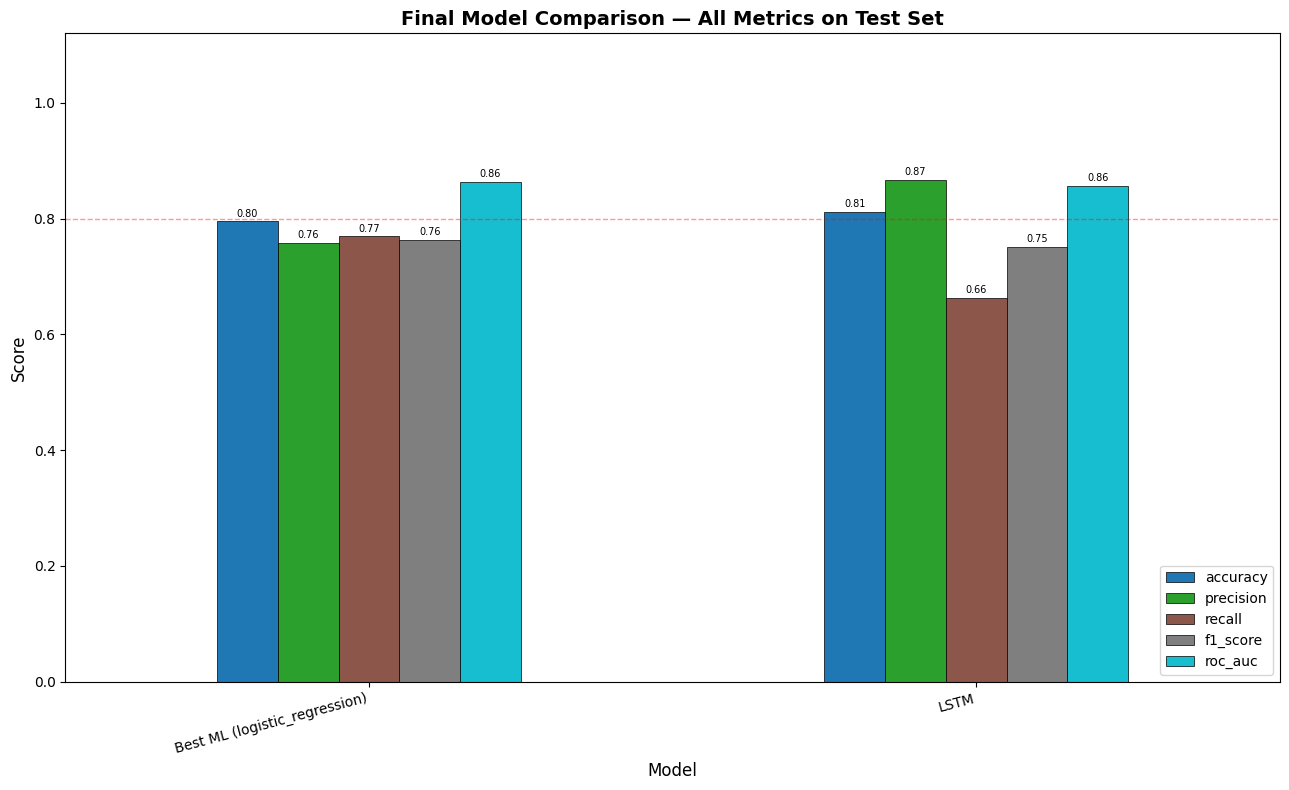

In [8]:
logger.info('Plotting unified metrics bar chart...')
metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
plot_df  = comparison_df[['model'] + metrics].set_index('model')
ax = plot_df.plot(kind='bar', figsize=(13, 8), colormap='tab10', edgecolor='black', linewidth=0.5)
ax.set_title('Final Model Comparison — All Metrics on Test Set', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=10)
ax.set_ylim(0, 1.12)
ax.legend(loc='lower right', fontsize=10)
ax.axhline(y=0.80, color='red', linestyle='--', linewidth=1, alpha=0.4)
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'final_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info('Metrics bar chart saved.')

---
### **SECTION 3 — LSTM Accuracy Curve (Train vs Validation)**

Notebook 4 saved training history to `models/lstm_history.json` and plotted the **loss curve**.
Here we load that same history and plot the **accuracy curve** to complement it — showing how
train vs validation accuracy evolved across epochs and whether the model overfit.

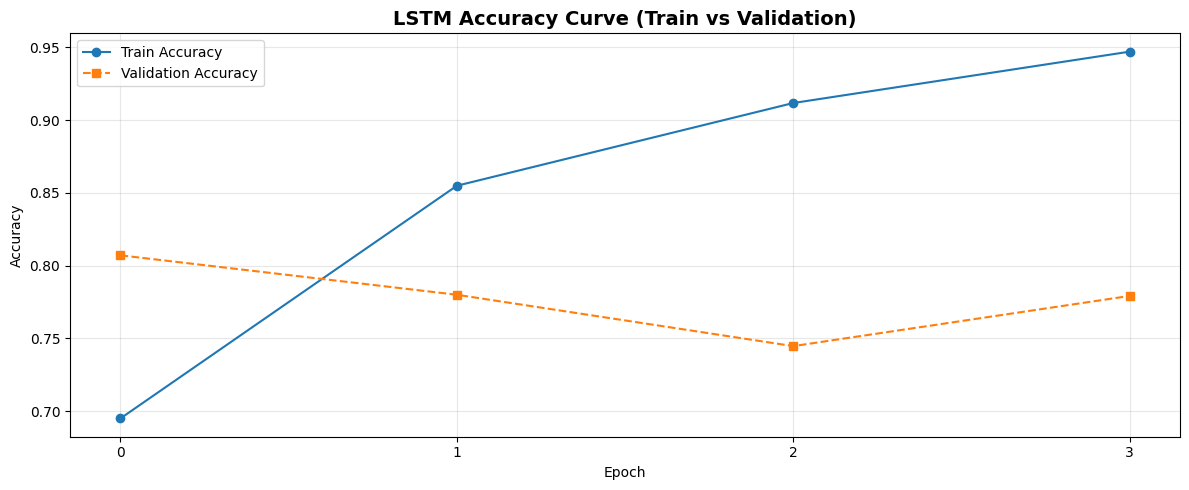

In [9]:
logger.info('Loading LSTM training history saved by Notebook 4...')

history_path = MODEL_DIR / 'lstm_history.json'

if not history_path.exists():
    raise FileNotFoundError(
        "lstm_history.json not found. "
        "Re-run Notebook 4 — it saves history after model.save()."
    )

with open(history_path) as f:
    hist = json.load(f)

logger.info('LSTM history loaded: epochs=%d', len(hist['loss']))

# Plot accuracy curve — NB4 already plotted the loss curve;
# here we add the accuracy curve to complement it
plt.figure(figsize=(12, 5))
plt.plot(hist['accuracy'],     marker='o',              label='Train Accuracy')
plt.plot(hist['val_accuracy'], marker='s', linestyle='--', label='Validation Accuracy')
plt.title('LSTM Accuracy Curve (Train vs Validation)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(len(hist['accuracy'])))
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'lstm_accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()
logger.info('LSTM accuracy curve plotted.')

---
### **SECTION 4 — Threshold Tuning on Best Model**

Not done in any prior notebook. For disaster detection **high Recall is critical** — a missed real disaster is far more costly than a false alarm. We scan thresholds to find the best F1 and examine the Recall trade-off.

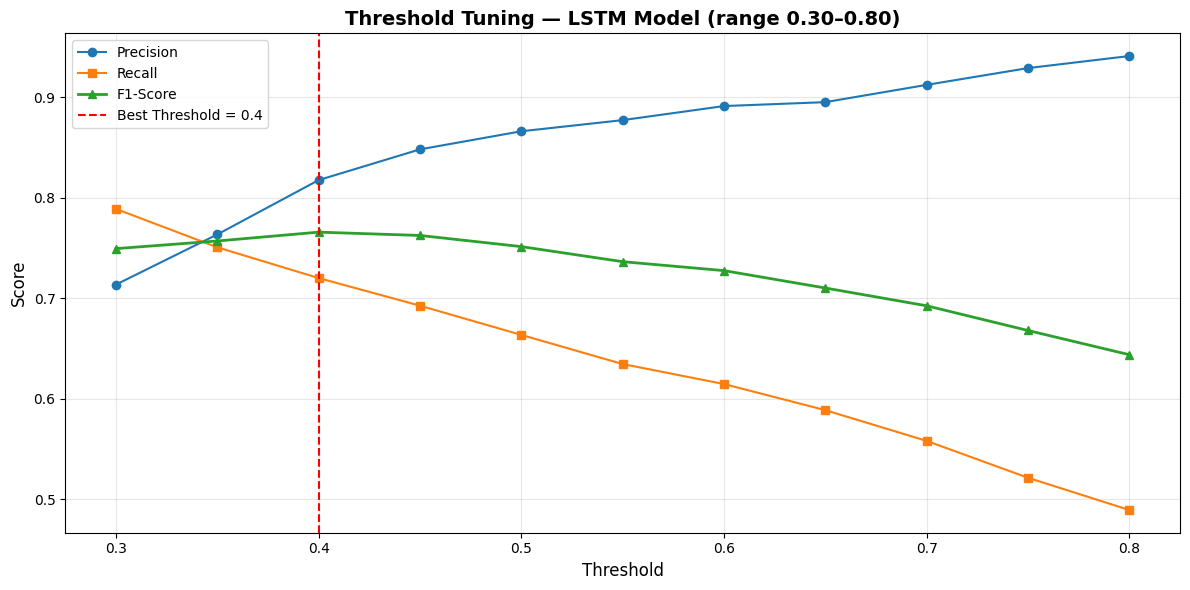


Best threshold (by F1, range 0.30–0.80): 0.4
 threshold  precision  recall  f1_score
      0.30     0.7137  0.7890    0.7495
      0.35     0.7636  0.7508    0.7571
      0.40     0.8177  0.7202    0.7659
      0.45     0.8483  0.6927    0.7626
      0.50     0.8663  0.6636    0.7515
      0.55     0.8774  0.6346    0.7365
      0.60     0.8914  0.6147    0.7276
      0.65     0.8953  0.5887    0.7103
      0.70     0.9125  0.5581    0.6926
      0.75     0.9292  0.5214    0.6680
      0.80     0.9412  0.4893    0.6439


In [10]:
logger.info('Performing threshold tuning on LSTM predictions...')

# Sweep thresholds from 0.30 to 0.80 only.
# Starting below 0.30 can produce unrealistically low thresholds:
# a model with high recall will maximise F1 at a very low cutoff,
# but that just means it flags almost everything as Disaster.
thresholds        = np.arange(0.30, 0.81, 0.05)
threshold_results = []
for thresh in thresholds:
    y_thresh = (lstm_prob >= thresh).astype(int)
    threshold_results.append({
        'threshold': round(float(thresh), 2),
        'precision': round(precision_score(y_test, y_thresh, zero_division=0), 4),
        'recall':    round(recall_score(y_test, y_thresh, zero_division=0), 4),
        'f1_score':  round(f1_score(y_test, y_thresh, zero_division=0), 4),
    })

thresh_df       = pd.DataFrame(threshold_results)
best_thresh_row = thresh_df.loc[thresh_df['f1_score'].idxmax()]
BEST_THRESHOLD  = float(best_thresh_row['threshold'])

# Safety clamp: never go below 0.40 regardless of tuning result
if BEST_THRESHOLD < 0.40:
    logger.warning('Best threshold %.2f is below 0.40 — clamping to 0.50', BEST_THRESHOLD)
    BEST_THRESHOLD = 0.50

plt.figure(figsize=(12, 6))
plt.plot(thresh_df['threshold'], thresh_df['precision'], marker='o', label='Precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'],    marker='s', label='Recall')
plt.plot(thresh_df['threshold'], thresh_df['f1_score'],  marker='^', linewidth=2, label='F1-Score')
plt.axvline(x=BEST_THRESHOLD, color='red', linestyle='--', label=f'Best Threshold = {BEST_THRESHOLD}')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Threshold Tuning — LSTM Model (range 0.30–0.80)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_DIR / 'threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nBest threshold (by F1, range 0.30–0.80): {BEST_THRESHOLD}')
print(thresh_df.to_string(index=False))
logger.info('Threshold tuning complete. Best threshold: %.2f', BEST_THRESHOLD)


---
### **SECTION 5 — Final Model Selection**

In [11]:
logger.info('Selecting final model...')
best_row         = comparison_df.iloc[0]
FINAL_MODEL_NAME = best_row['model']
print(f'''
Final Model       : {FINAL_MODEL_NAME}
Accuracy          : {best_row['accuracy']}
Precision         : {best_row['precision']}
Recall            : {best_row['recall']}
F1-Score          : {best_row['f1_score']}
ROC-AUC           : {best_row['roc_auc']}
Decision Threshold: {BEST_THRESHOLD}
''')
logger.info('Final model: %s | F1: %.4f | Threshold: %.2f', FINAL_MODEL_NAME, best_row['f1_score'], BEST_THRESHOLD)


Final Model       : Best ML (logistic_regression)
Accuracy          : 0.7951
Precision         : 0.7575
Recall            : 0.7691
F1-Score          : 0.7633
ROC-AUC           : 0.8639
Decision Threshold: 0.4



---
### **SECTION 6 — Save Evaluation Outputs**

In [12]:
logger.info('Saving evaluation outputs...')
comparison_df.to_csv(REPORT_DIR / 'final_evaluation_results.csv', index=False)
thresh_df.to_csv(REPORT_DIR / 'threshold_tuning_results.csv', index=False)
is_lstm  = 'LSTM' in FINAL_MODEL_NAME
metadata = {
    'best_model':       FINAL_MODEL_NAME,
    'is_deep_learning': is_lstm,
    'best_threshold':   BEST_THRESHOLD,
    'f1_score':         float(best_row['f1_score']),
    'accuracy':         float(best_row['accuracy']),
    'precision':        float(best_row['precision']),
    'recall':           float(best_row['recall']),
    'roc_auc':          float(best_row['roc_auc']) if best_row['roc_auc'] else None,
    'vocab_size':       VOCAB_SIZE,
    'max_len':          MAX_LEN,
}
with open(MODEL_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)
# Save the LSTM tokenizer so Notebook 6 can load it directly
# without rebuilding it from training data a third time
pickle.dump(lstm_tokenizer, open(MODEL_DIR / 'lstm_tokenizer.pkl', 'wb'))

print('Saved:')
print('  - reports/final_evaluation_results.csv')
print('  - reports/threshold_tuning_results.csv')
print('  - models/model_metadata.json')
print('  - models/lstm_tokenizer.pkl')
print(json.dumps(metadata, indent=4))
logger.info('All outputs saved including lstm_tokenizer.pkl.')
logger.info('==== FINAL MODEL EVALUATION PIPELINE COMPLETED ====')

Saved:
  - reports/final_evaluation_results.csv
  - reports/threshold_tuning_results.csv
  - models/model_metadata.json
  - models/lstm_tokenizer.pkl
{
    "best_model": "Best ML (logistic_regression)",
    "is_deep_learning": false,
    "best_threshold": 0.4,
    "f1_score": 0.7633,
    "accuracy": 0.7951,
    "precision": 0.7575,
    "recall": 0.7691,
    "roc_auc": 0.8639,
    "vocab_size": 10000,
    "max_len": 100
}


---
### **Notebook 5 Summary**

| Step | Why it is new |
|---|---|
| Unified metrics table — ML vs LSTM, same test set | NB3 evaluated ML on full data; NB4 gave LSTM F1 only |
| Side-by-side metrics bar chart | First cross-model visual |
| LSTM accuracy curve (train vs val) | NB4 only plotted loss curve |
| Threshold tuning | Not done in any prior notebook |
| `model_metadata.json` | Required by Notebook 6 |

**Next Step → Notebook 6: Deployment**